In [1]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob

In [2]:
!ls /scr/raf/Prod_Data/CSET/

3V-CPI	     CSETrf04.nc  CSETrf08.nc  CSETrf12.nc  CSETrf16.nc  MTP
CSETrf01.nc  CSETrf05.nc  CSETrf09.nc  CSETrf13.nc  HRT		 RAF-CO
CSETrf02.nc  CSETrf06.nc  CSETrf10.nc  CSETrf14.nc  KML		 sha256sum.CSET
CSETrf03.nc  CSETrf07.nc  CSETrf11.nc  CSETrf15.nc  LRT


In [3]:
# set this up to point to the libararies directory in ml-holodec
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'Optics')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)

In [4]:
import MieLibrary as mie

In [5]:
cset_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/CSET/","*.nc"))

In [75]:
ds = xr.open_dataset(cset_lst[4])

In [76]:
ds

<xarray.Dataset>
Dimensions:                 (Time: 27481, sps1: 1, Vector64: 64, Vector31: 31,
                             Vector100: 100, interarrival_endpoints: 41,
                             Vector129: 129, Vector257: 257)
Coordinates:
  * Time                    (Time) datetime64[ns] 2015-07-14T16:40:00 ... 201...
  * interarrival_endpoints  (interarrival_endpoints) float32 1e-07 ... 10.0
Dimensions without coordinates: sps1, Vector64, Vector31, Vector100, Vector129,
                                Vector257
Data variables: (12/220)
    ACINS                   (Time) float32 ...
    ADIFR                   (Time) float32 ...
    ALT                     (Time) float32 ...
    BDIFR                   (Time) float32 ...
    BLATA                   (Time) float32 ...
    BLONGA                  (Time) float32 ...
    ...                      ...
    NACCEPT2D3A_3V          (Time) float32 ...
    NREJECT2D3R_3V          (Time) float32 ...
    NREJECT2D3A_3V          (Time) float32 ...
    A1DC_LWOO               (Time, sps1, Vector64) float32 ...
    ACDP_LWOI               (Time, sps1, Vector31) float32 ...
    AUHSAS_RWOOU            (Time, sps1, Vector100) float32 ...
Attributes: (12/38)
    institution:                   NCAR Research Aviation Facility
    Address:                       P.O. Box 3000, Boulder, CO 80307-3000
    Phone:                         (303) 497-1030
    creator_url:                   http://www.eol.ucar.edu
    creator_email:                 codiac at ucar.edu
    Conventions:                   NCAR-RAF/nimbus
    ...                            ...
    geospatial_vertical_units:     m
    wind_field:                    WSC WDC WIC
    landmarks:                     39.9088 -105.117 jeffco
    Categories:                    Position,Thermodynamic,Aircraft State,Atmo...
    time_coverage_start:           2015-07-14T16:40:00 +0000
    time_coverage_end:             2015-07-15T00:18:00 +0000

Relevant variables

`CUHSAS_RWOOU` : Particle Concentration #/cm^3

`AUHSAS_RWOOU` : UHSAS Raw Count Histogram

In [77]:
ds['CUHSAS_RWOOU']

<xarray.DataArray 'CUHSAS_RWOOU' (Time: 27481, sps1: 1, Vector100: 100)>
[2748100 values with dtype=float32]
Coordinates:
  * Time     (Time) datetime64[ns] 2015-07-14T16:40:00 ... 2015-07-15T00:18:00
Dimensions without coordinates: sps1, Vector100
Attributes: (12/13)
    units:          #/cm3
    long_name:      UHSAS Concentration (per cell)
    actual_range:   [   0.     1032.9238]
    Category:       PMS Probe
    SerialNumber:   UHSAS001
    DataQuality:    Good
    ...             ...
    FirstBin:       9
    LastBin:        99
    CellSizes:      [0.06    0.06173 0.06351 0.06534 0.06722 0.06916 0.07115 ...
    CellSizeUnits:  micrometers
    CellSizeNote:   CellSizes are upper bin limits as diameter.
    HistogramNote:  Zeroth data bin is an unused legacy placeholder.

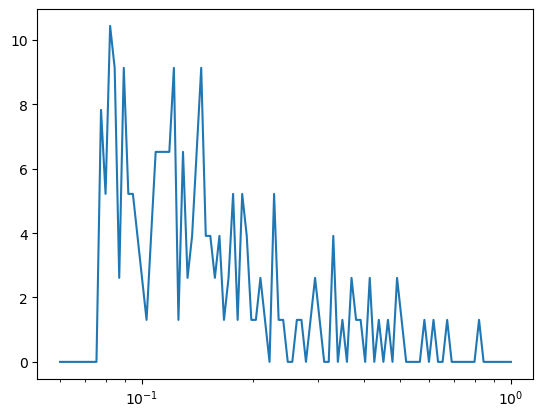

In [80]:
plt.figure()
plt.plot(ds['CUHSAS_RWOOU'].attrs['CellSizes'],ds['CUHSAS_RWOOU'].values[5000,0,:])
plt.xscale('log')

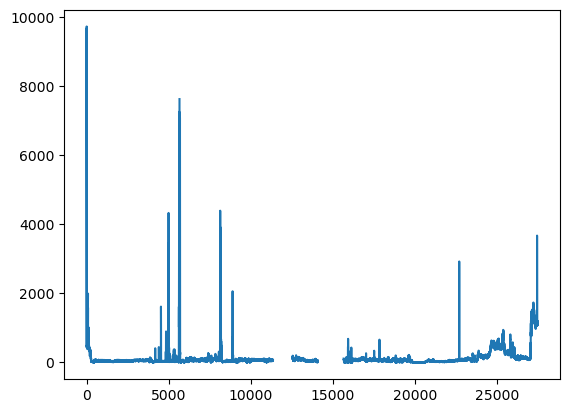

In [81]:
plt.figure()
plt.plot(np.sum(ds['CUHSAS_RWOOU'].values[:,0,:],axis=1))

In [82]:
part_diam = ds['CUHSAS_RWOOU'].attrs['CellSizes']*1e-6

In [83]:
# wavelen = 532e-9
wavelen_lst = [1064e-9, 532e-9, 355e-9]
index_refrac = 1.5

In [84]:
r_arr = part_diam/2
ang_arr = np.linspace(0,500e-6,100)
dang=np.diff(ang_arr)

In [85]:
solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)

In [86]:
r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)

In [87]:
sig_pi = np.zeros((len(wavelen_lst),r_arr.size))
sig_e = np.zeros((len(wavelen_lst),r_arr.size))

for wl_idx, wavelen in enumerate(wavelen_lst):
    k_num = 2*np.pi/wavelen
    for r_idx,r_val in enumerate(r_arr):
        x_val = 2*np.pi*r_val/wavelen
        Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
        sig_pi[wl_idx,r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr))
        sig_e[wl_idx,r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2

In [99]:
beta_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
alpha_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
for idx in range(len(wavelen_lst)):
    beta_coef[idx,:] = np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*1e6*sig_pi[idx,:][np.newaxis,:],axis=1)/solid_angle
    alpha_coef[idx,:] = np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*1e6*sig_e[idx,:][np.newaxis,:],axis=1)
number_conc = np.trapz(ds['CUHSAS_RWOOU'].values.squeeze(),axis=1)
mean_r = np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
mean_ln_r = np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)


/tmp/ipykernel_3038844/486315828.py:7: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_3038844/486315828.py:8: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_3038844/486315828.py:9: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
/tmp/ipykernel_3038844/486315828.py:9: RuntimeWarning: invalid value encountered in sqrt
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_RWOOU'].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)


Text(0, 0.5, 'mean log radius')

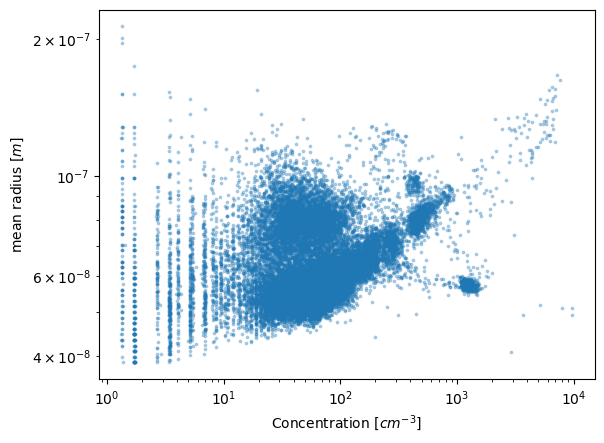

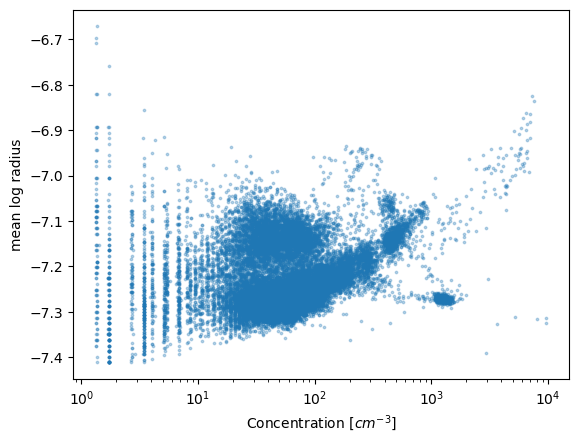

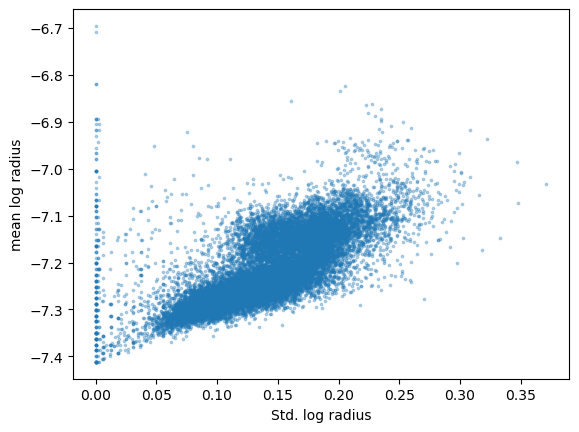

In [100]:
plt.figure()
plt.scatter(number_conc,mean_r,s=3,alpha=0.3)
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel('mean radius [$m$]')
plt.xscale('log')
plt.yscale('log')

plt.figure()
plt.scatter(number_conc,mean_ln_r,s=3,alpha=0.3)
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel('mean log radius')
plt.xscale('log')


plt.figure()
plt.scatter(std_ln_r,mean_ln_r,s=3,alpha=0.3)
plt.xlabel('Std. log radius')
plt.ylabel('mean log radius')

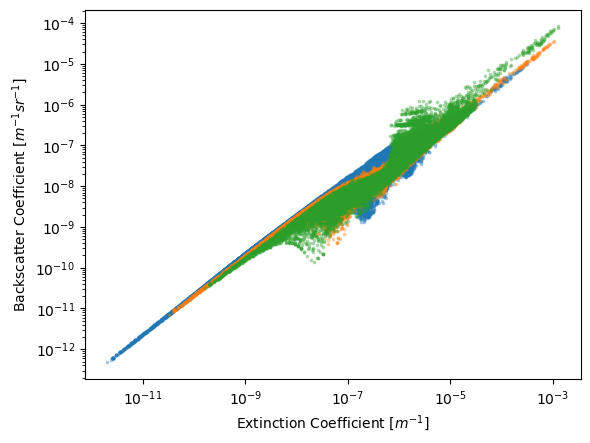

In [90]:
plt.figure()
for idx in range(len(wavelen_lst)):
    plt.scatter(alpha_coef[idx,:],beta_coef[idx,:],s=3,alpha=0.3)
plt.xlabel("Extinction Coefficient [$m^{-1}$]")
plt.ylabel("Backscatter Coefficient [$m^{-1}sr^{-1}$]")
plt.xscale('log')
plt.yscale('log')

Text(0, 0.5, 'Extinction Coefficient [$m^{-1}$]')

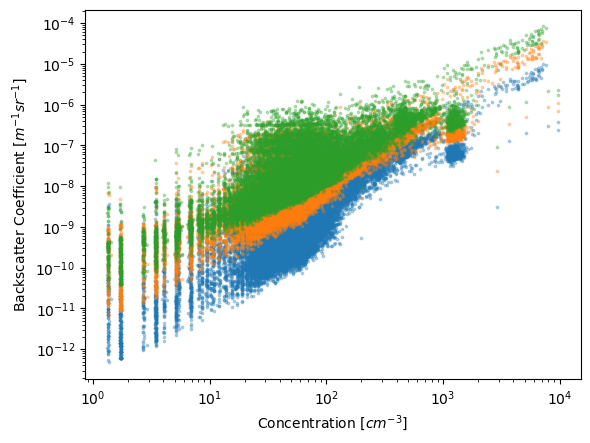

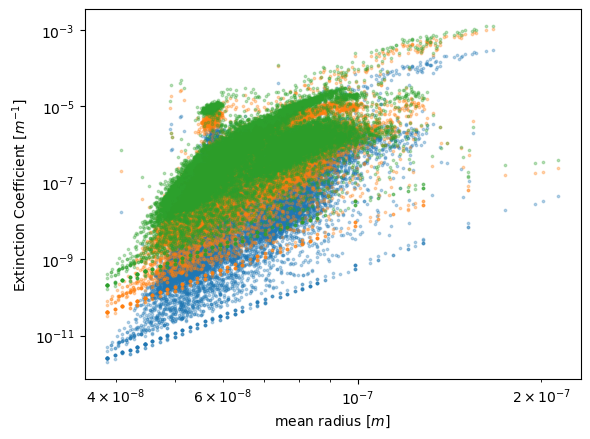

In [95]:
plt.figure()
for idx in range(len(wavelen_lst)):
    plt.scatter(number_conc,beta_coef[idx,:],s=3,alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Concentration [$cm^{-3}$]')
plt.ylabel("Backscatter Coefficient [$m^{-1}sr^{-1}$]")

plt.figure()
for idx in range(len(wavelen_lst)):
    plt.scatter(mean_r,alpha_coef[idx,:],s=3,alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('mean radius [$m$]')
plt.ylabel("Extinction Coefficient [$m^{-1}$]")

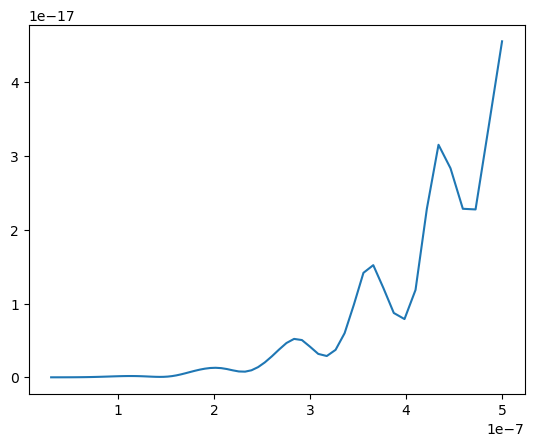

In [22]:
plt.figure()
plt.plot(r_arr,sig_pi/500e-6/2/np.pi)

In [ ]:
# test_ang_arr = np.linspace(0,180,1000)*np.pi/180
# Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, test_ang_arr)